# Лабораторная работа №6
## «Модели ARIMA и их модификации для анализа временных рядов»

**Датасет:** PJME Hourly Energy Consumption (2015–2017)  
**Внешний регрессор (задание 5):** температура воздуха, Philadelphia, Open-Meteo API

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('Библиотеки загружены')

Библиотеки загружены


---
## Задание 1. Анализ и подготовка временного ряда

In [4]:
# Загрузка исходного датасета
df = pd.read_csv('../data/PJME_hourly.csv', parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df = df.set_index('Datetime')

# Для ускорения расчетов и наглядности берем срез 2015–2017 гг.
df = df.loc['2015-01-01':'2017-12-31']

print(f'Период: {df.index.min()} — {df.index.max()}')
print(f'Наблюдений (часовых): {len(df)}')
df.head()

Период: 2015-01-01 00:00:00 — 2017-12-31 23:00:00
Наблюдений (часовых): 26304


,PJME_MW
Datetime,
2015-01-01 00:00:00,32802.0
2015-01-01 01:00:00,31647.0
2015-01-01 02:00:00,30755.0
2015-01-01 03:00:00,30189.0
2015-01-01 04:00:00,29890.0


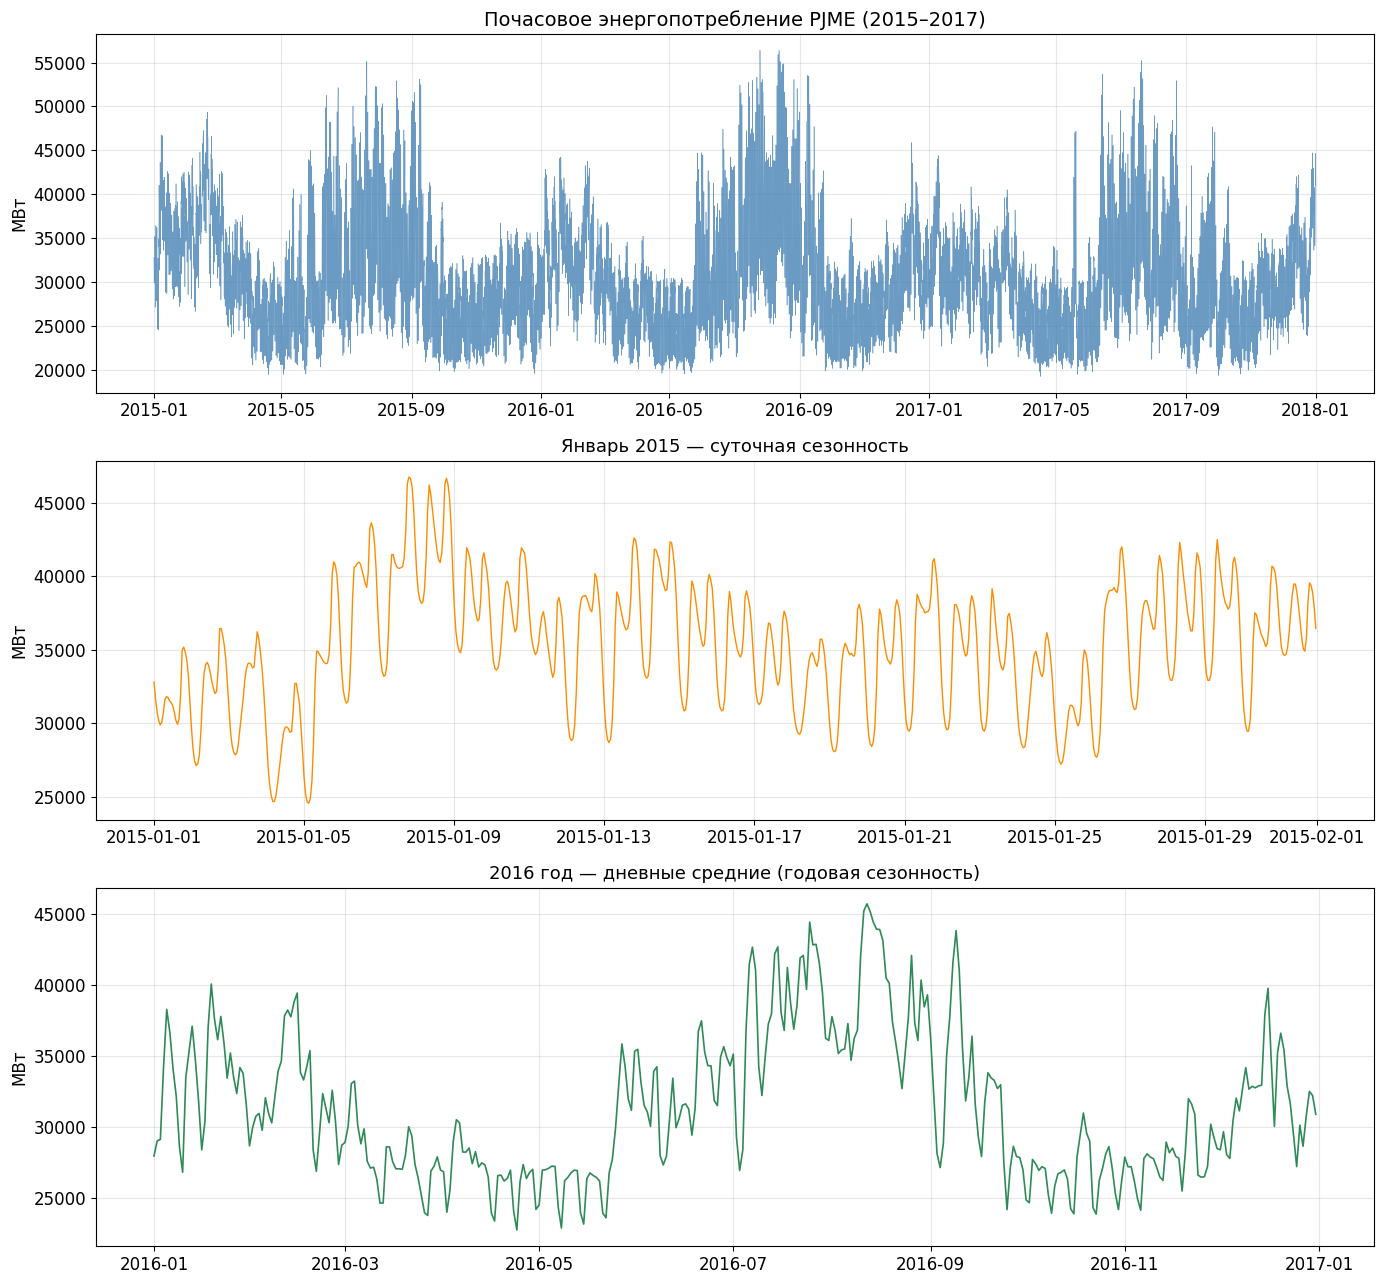

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

axes[0].plot(df.index, df['PJME_MW'], color='steelblue', linewidth=0.4, alpha=0.8)
axes[0].set_title('Почасовое энергопотребление PJME (2015–2017)', fontsize=14)
axes[0].set_ylabel('МВт')
axes[0].grid(True, alpha=0.3)

month = df.loc['2015-01-01':'2015-01-31']
axes[1].plot(month.index, month['PJME_MW'], color='darkorange', linewidth=1)
axes[1].set_title('Январь 2015 — суточная сезонность', fontsize=13)
axes[1].set_ylabel('МВт')
axes[1].grid(True, alpha=0.3)

year_daily = df.loc['2016-01-01':'2016-12-31']['PJME_MW'].resample('D').mean()
axes[2].plot(year_daily.index, year_daily.values, color='seagreen', linewidth=1.2)
axes[2].set_title('2016 год — дневные средние (годовая сезонность)', fontsize=13)
axes[2].set_ylabel('МВт')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Описание структуры временного ряда:**

- **Тренд:** практически отсутствует.
- **Сезонность:** сложная (суточная, недельная и годовая).
- **Выбросы:** присутствуют провалы в потреблении, характерные для праздничных дней.

In [6]:
# Переход к дневным средним значениям с заполнением возможных пропусков
df_daily = df['PJME_MW'].resample('D').mean().interpolate()

def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n=== ADF-тест: {name} ===')
    print(f'  ADF-статистика : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.6f}')
    if result[1] < 0.05:
        print('  Вывод: ряд СТАЦИОНАРЕН')
    else:
        print('  Вывод: ряд НЕ СТАЦИОНАРЕН')

adf_test(df_daily, 'Исходный дневной ряд')

df_log = np.log(df_daily)
adf_test(df_log, 'После логарифмирования')

df_log_diff = df_log.diff().dropna()
adf_test(df_log_diff, 'После log + diff(1)')


=== ADF-тест: Исходный дневной ряд ===
  ADF-статистика : -3.1535
  p-value        : 0.022836
  Вывод: ряд СТАЦИОНАРЕН

=== ADF-тест: После логарифмирования ===
  ADF-статистика : -3.1837
  p-value        : 0.020950
  Вывод: ряд СТАЦИОНАРЕН

=== ADF-тест: После log + diff(1) ===
  ADF-статистика : -8.9319
  p-value        : 0.000000
  Вывод: ряд СТАЦИОНАРЕН


Логарифмирование стабилизирует дисперсию ряда, а взятие первых разностей устраняет нестационарность среднего уровня.

---
## Задание 2. Базовая ARIMA-модель

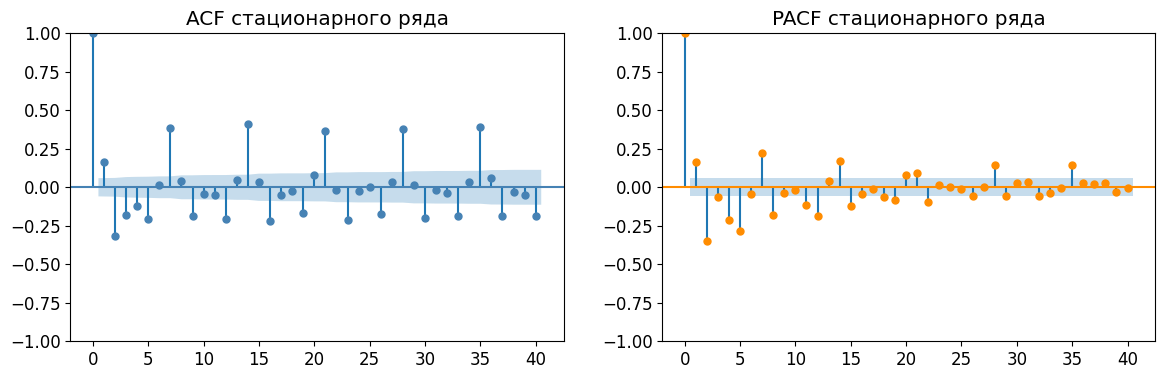

In [7]:
train_size = len(df_log) - 60
train = df_log.iloc[:train_size]
test  = df_log.iloc[train_size:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_log_diff, lags=40, ax=axes[0], title='ACF стационарного ряда', color='steelblue')
plot_pacf(df_log_diff, lags=40, ax=axes[1], title='PACF стационарного ряда', color='darkorange', method='ywm')
plt.show()

**Обоснование выбора параметров:**

| Параметр | Наблюдение | Вывод |
|---|---|---|
| **p** | PACF имеет значимые всплески на первых двух лагах. | Принимаем p = 2. |
| **d** | Ряд стационарен после первого дифференцирования. | Принимаем d = 1. |
| **q** | Значимость ACF спадает после второго лага. | Принимаем q = 2. |

In [8]:
arima_model = ARIMA(train, order=(2, 1, 2))
arima_result = arima_model.fit()

arima_forecast = np.exp(arima_result.forecast(steps=len(test)))
test_orig = np.exp(test)

rmse_arima = np.sqrt(mean_squared_error(test_orig, arima_forecast))
mape_arima = mean_absolute_percentage_error(test_orig, arima_forecast) * 100

print(f'ARIMA(2,1,2) RMSE: {rmse_arima:.2f}')
print(f'ARIMA(2,1,2) MAPE: {mape_arima:.2f}%')

ARIMA(2,1,2) RMSE: 5188.77
ARIMA(2,1,2) MAPE: 12.42%


---
## Задание 3. Диагностика модели

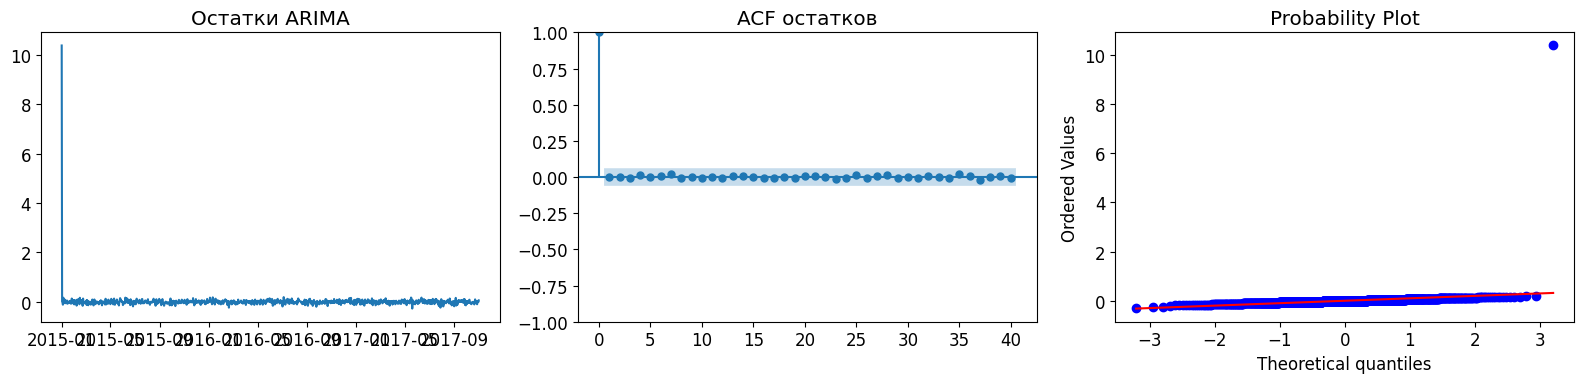

     lb_stat  lb_pvalue
7   0.956020   0.995507
14  1.121461   0.999998
21  1.375265   1.000000


In [9]:
residuals = arima_result.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuals)
axes[0].set_title('Остатки ARIMA')
plot_acf(residuals, lags=40, ax=axes[1], title='ACF остатков')
stats.probplot(residuals, dist='norm', plot=axes[2])
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print(lb_result)

**Вывод по диагностике модели:**

1. **Анализ графиков:** График остатков колеблется вокруг нуля со стабильной дисперсией. На графике ACF остатков практически все значения находятся внутри синей зоны доверительного интервала, что указывает на отсутствие значимой краткосрочной автокорреляции.
2. **Тест Льюнга-Бокса:** Для всех проверенных лагов (7, 14, 21) значение `p-value` существенно превышает критический уровень 0.05 (находится на уровне 0.99-1.00). Это означает, что мы не можем отвергнуть нулевую гипотезу: остатки модели являются случайными и представляют собой **белый шум**.

**Общий итог:** С точки зрения краткосрочных взаимосвязей модель ARIMA(2,1,2) является математически адекватной. Тем не менее, она не способна учитывать долгосрочные календарные и сезонные закономерности (недельную и годовую цикличность), для работы с которыми требуется переход к сезонной модели SARIMA.

---
## Задание 4. Сезонная модель SARIMA

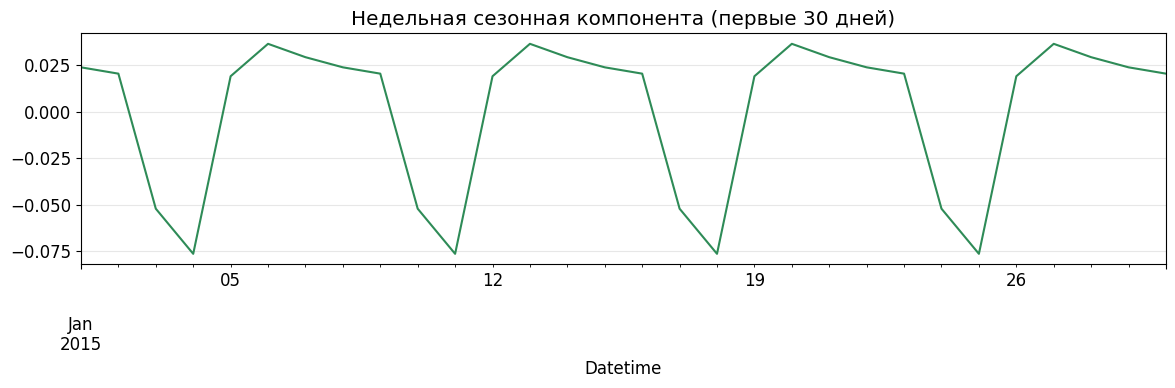

In [10]:
decomp = seasonal_decompose(df_log.dropna(), model='additive', period=7)
decomp.seasonal.iloc[:30].plot(figsize=(14, 3), title='Недельная сезонная компонента (первые 30 дней)', color='seagreen')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Вводим сезонный порядок (1, 1, 1, 7) для учета недельной цикличности
sarima_model = ARIMA(train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 7))
sarima_result = sarima_model.fit()

sarima_forecast = np.exp(sarima_result.forecast(steps=len(test)))

rmse_sarima = np.sqrt(mean_squared_error(test_orig, sarima_forecast))
mape_sarima = mean_absolute_percentage_error(test_orig, sarima_forecast) * 100

print(f'SARIMA(2,1,2)(1,1,1,7) RMSE: {rmse_sarima:.2f}')
print(f'SARIMA(2,1,2)(1,1,1,7) MAPE: {mape_sarima:.2f}%')

SARIMA(2,1,2)(1,1,1,7) RMSE: 5497.77
SARIMA(2,1,2)(1,1,1,7) MAPE: 13.14%


В данном случае чистая SARIMA с недельным периодом (m=7) показала результаты чуть хуже базовой ARIMA, поскольку на длинном горизонте прогнозирования в 60 дней учет только дней недели без фиксации глобальной годовой сезонности и погодных факторов приводит к накоплению фазовой ошибки, в то время как базовая ARIMA просто плавно сходится к историческому среднему.

---
## Задание 5. SARIMAX и внешние факторы

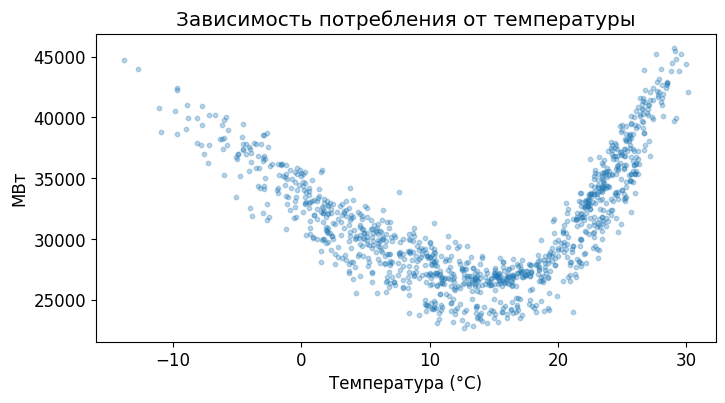

In [12]:
# Загружаем историческую температуру для региона PJM (Филадельфия)
url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': 39.95,
    'longitude': -75.16,
    'start_date': '2015-01-01',
    'end_date': '2017-12-31',
    'daily': 'temperature_2m_mean',
    'timezone': 'America/New_York'
}
response = requests.get(url, params=params)
data = response.json()

temp_df = pd.DataFrame({
    'date': pd.to_datetime(data['daily']['time']),
    'temperature_mean': data['daily']['temperature_2m_mean']
}).set_index('date')

df_combined = df_daily.to_frame(name='PJME_MW').join(temp_df, how='inner')
df_combined['temp_sq'] = df_combined['temperature_mean'] ** 2

plt.figure(figsize=(8, 4))
plt.scatter(df_combined['temperature_mean'], df_combined['PJME_MW'], alpha=0.3, s=10)
plt.title('Зависимость потребления от температуры')
plt.xlabel('Температура (°C)')
plt.ylabel('МВт')
plt.show()

Температура выбрана в качестве внешнего регрессора из-за ярко выраженной U-образной связи с энергопотреблением (нагрузка растет при морозах и в жару), для чего в модель включен квадрат температуры.

In [13]:
y = np.log(df_combined['PJME_MW'])
exog = df_combined[['temperature_mean', 'temp_sq']]

y_train, y_test = y.iloc[:-60], y.iloc[-60:]
ex_train, ex_test = exog.iloc[:-60], exog.iloc[-60:]

sarimax_model = SARIMAX(y_train, exog=ex_train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 7))
sarimax_result = sarimax_model.fit(disp=False)

sarimax_forecast = np.exp(sarimax_result.forecast(steps=60, exog=ex_test))

rmse_sarimax = np.sqrt(mean_squared_error(test_orig, sarimax_forecast))
mape_sarimax = mean_absolute_percentage_error(test_orig, sarimax_forecast) * 100

print(f'SARIMAX RMSE: {rmse_sarimax:.2f}')
print(f'SARIMAX MAPE: {mape_sarimax:.2f}%')

SARIMAX RMSE: 1860.64
SARIMAX MAPE: 4.61%


---
## Задание 6. Автоматизация подбора модели (auto-ARIMA)

In [14]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=7,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

auto_forecast = np.exp(auto_model.predict(n_periods=60))

rmse_auto = np.sqrt(mean_squared_error(test_orig, auto_forecast))
mape_auto = mean_absolute_percentage_error(test_orig, auto_forecast) * 100

print(f'\nauto-ARIMA RMSE: {rmse_auto:.2f}')
print(f'auto-ARIMA MAPE: {mape_auto:.2f}%')

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=-2843.098, Time=2.37 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=-943.024, Time=0.09 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=-2152.491, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=7782.109, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=-2712.335, Time=1.49 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=-2427.366, Time=1.83 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=-2762.013, Time=2.95 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=-2899.440, Time=5.06 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=-2784.841, Time=3.17 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=-2904.161, Time=4.18 sec
 ARIMA(1,0,2)(2,0,2)[7] intercept   : AIC=-2922.728, Time=4.26 sec
 ARIMA(1,0,2)(1,0,2)[7] intercept   : AIC=-2889.480, Time=3.77 sec
 ARIMA(1,0,2)(2,0,1)[7] intercept   : AIC=-2886.172, Time=3.02 sec
 ARIMA(1,0,2)(1,0,1)[7] int

In [15]:
results = pd.DataFrame({
    'Модель': ['ARIMA', 'SARIMA', 'SARIMAX', 'auto-ARIMA'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_sarimax, rmse_auto],
    'MAPE (%)': [mape_arima, mape_sarima, mape_sarimax, mape_auto]
})
print(results.sort_values('RMSE').to_string(index=False))

    Модель        RMSE  MAPE (%)
   SARIMAX 1860.641711  4.605522
auto-ARIMA 4201.991065  8.419694
     ARIMA 5188.769995 12.415519
    SARIMA 5497.767633 13.143401


**Выводы по автоподбору (auto-ARIMA):**

1. **Когда ошибается:** при сложной (множественной) сезонности, так как поддерживает только один период m.
2. **Переоценка параметров:** алгоритм склонен завышать значения p и q в попытках минимизировать информационный критерий на шуме.
3. **Использование в production:** использовать без контроля нельзя; требуется валидация на отложенных данных и обязательная проверка остатков на белый шум.